# Read in and Filter Data
Colexification must exist in at least 3 languages

In [1]:
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
import community as community_louvain 

# 1. Load the raw data
df = pd.read_csv('./colexifications.csv')

# Filter
# a connection exists in at least 3 distinct language families 
df_filtered = df[df['Family_Count'] >= 3]

# 3. Build the Graph
G_full = nx.from_pandas_edgelist(
    df_filtered, 
    source='Source_Concept', 
    target='Target_Concept', 
    edge_attr='Family_Count'
)

# Find all disconnected islands, sort them by size, grab the largest
components = sorted(nx.connected_components(G_full), key=len, reverse=True)
G = G_full.subgraph(components[0]).copy()

print(f"Full Network Nodes: {G_full.number_of_nodes()}")
print(f"Giant Component Nodes: {G.number_of_nodes()}")
print(f"We retained {G.number_of_nodes() / G_full.number_of_nodes() * 100:.2f}% of nodes in the Giant Component.")

Full Network Nodes: 1386
Giant Component Nodes: 1300
We retained 93.80% of nodes in the Giant Component.


# Power Law and Small World

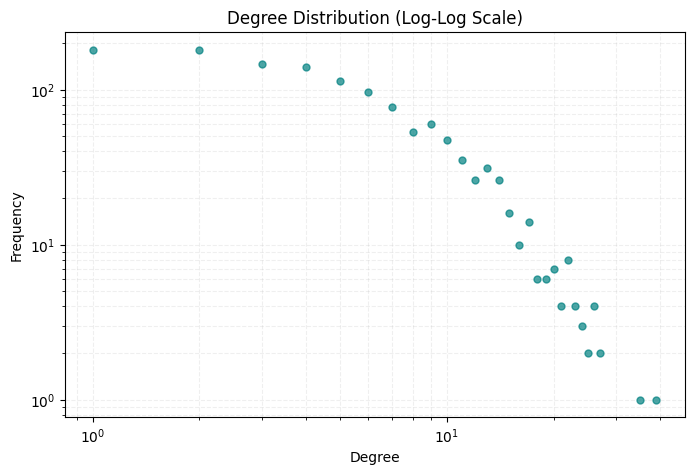


--- Model Properties ---
Average Path Length: 4.89 steps
Clustering Coefficient: 0.2982


In [2]:
from collections import Counter
import matplotlib.pyplot as plt
import networkx as nx


# 1. Power Law / Degree Distribution
degrees = [d for n, d in G.degree()]

# Count how many nodes have each degree
degree_counts = Counter(degrees)
x = list(degree_counts.keys())    # degree (k)
y = list(degree_counts.values())  # frequency (P(k))

plt.figure(figsize=(8, 5))
# plt.loglog
plt.loglog(x, y, 'o', color='teal', markersize=5, alpha=0.7)

plt.title("Degree Distribution (Log-Log Scale)")
plt.xlabel("Degree")
plt.ylabel("Frequency")
plt.grid(True, which="both", ls="--", alpha=0.2)
plt.show()

# Model Properties
avg_path_length = nx.average_shortest_path_length(G)
clustering_coefficient = nx.average_clustering(G)

print(f"\n--- Model Properties ---")
print(f"Average Path Length: {avg_path_length:.2f} steps")
print(f"Clustering Coefficient: {clustering_coefficient:.4f}")

# Centrality & Modularity

In [ ]:
# 1. Centrality Calculations
betweenness = nx.betweenness_centrality(G, weight='Family_Count')
degree_cent = nx.degree_centrality(G)
eigenvector = nx.eigenvector_centrality(G, weight='Family_Count', max_iter=1000)
closeness = nx.closeness_centrality(G)
pagerank = nx.pagerank(G, weight='Family_Count')

# Helper function to sort the top 5
def get_top_5(centrality_dict):
    return sorted(centrality_dict.items(), key=lambda x: x[1], reverse=True)[:5]

# Print the rankings
print("Top 5 Betweenness")
for node, score in get_top_5(betweenness):
    print(f"{node}: {score:.4f}")

print("\nTop 5 Degree")
for node, score in get_top_5(degree_cent):
    print(f"{node}: {score:.4f}")

print("\nTop 5 Eigenvector")
for node, score in get_top_5(eigenvector):
    print(f"{node}: {score:.4f}")

print("\nTop 5 Closeness")
for node, score in get_top_5(closeness):
    print(f"{node}: {score:.4f}")

print("\nTop 5 PageRank")
for node, score in get_top_5(pagerank):
    print(f"{node}: {score:.4f}")

# 2. Modularity
partition = community_louvain.best_partition(G, weight='Family_Count')
modularity_score = community_louvain.modularity(partition, G, weight='Family_Count')

print(f"\n Modularity")
print(f"Modularity Score (Q): {modularity_score:.4f}")
print(f"Detected {len(set(partition.values()))} distinct communities.")

Top 5 Betweenness
SAY: 0.0821
DIE: 0.0623
BE ALIVE: 0.0528
DO: 0.0518
BURNING: 0.0515

Top 5 Degree
SAY: 0.0300
DO: 0.0269
EAT: 0.0208
STRIKE: 0.0208
DIE: 0.0200

Top 5 Eigenvector
YOUNGER BROTHER (OF WOMAN): 0.3657
YOUNGER BROTHER (OF MAN): 0.3623
YOUNGER SISTER (OF MAN): 0.3611
YOUNGER SISTER (OF WOMAN): 0.3606
OLDER SISTER (OF MAN): 0.3416

Top 5 Closeness
DIE: 0.3008
EAT: 0.2992
BURNING: 0.2985
COME: 0.2980
SAY: 0.2979

Top 5 PageRank
BURN (SOMETHING): 0.0035
STRIKE: 0.0034
THINK (BELIEVE): 0.0034
THINK (REFLECT): 0.0032
BURNING: 0.0032

 Modularity
Modularity Score (Q): 0.8220
Detected 33 distinct communities.


## Initial Neighborgood Analysis

In [4]:
from collections import defaultdict

# Group concepts
community_dict = defaultdict(list)
for node, comm_id in partition.items():
    community_dict[comm_id].append(node)

# 2. Sort by size
sorted_communities = sorted(community_dict.values(), key=len, reverse=True)

print(f"Total Neighborhoods: {len(sorted_communities)}\n")

# 3. Print the top 10 
for i, cluster in enumerate(sorted_communities[:10]):
    print(f"--- Neighborhood {i+1} (Size: {len(cluster)} concepts) ---")
    
    # Print the first 20 words
    preview = ", ".join(cluster[:20])
    if len(cluster) > 20:
        preview += " ..."
        
    print(f"{preview}\n")

Total Neighborhoods: 33

--- Neighborhood 1 (Size: 106 concepts) ---
DIE, MORTAR BINDER, SHOOT, DIG, EXTINGUISH, KILL, MURDER, DIVORCE, THROW, DO, STRIKE, PREGNANT, THING, LAME, LIMP, CROOKED, CORPSE, PULL OFF (SKIN), PEEL, BRAID ...

--- Neighborhood 2 (Size: 104 concepts) ---
LOOK, SEE, CRY, SAY, SOUND OR NOISE, SMELL (PERCEIVE), NAME, SING, KNOW (SOMETHING), GILL, EAR, MIND, BRAIN, ROTTEN, EARLOBE, HEAR, EARRING, PUS, LANGUAGE, WORD ...

--- Neighborhood 3 (Size: 85 concepts) ---
WALK, GROW, BE ALIVE, LEAVE, COME, GO, MOSQUITO, FLY (INSECT), CENTIPEDE, SCORPION, SPIDER, FLY (MOVE THROUGH AIR), SANDFLY, SIT, STAND, FALL, DRIBBLE, DRIP (EMIT LIQUID), DWELL (LIVE, RESIDE), WAKE UP ...

--- Neighborhood 4 (Size: 80 concepts) ---
SIDE, NEAR, END (OF SPACE), SHORE, NOSE, FOREHEAD, WALL (OF HOUSE), EDGE, TOOTH, SHARP, CAPE, POINTED, FRUIT, EGG, EYE, STAR, FIREFLY, COMMON COLD (DISEASE), BAMBOO, CEASE ...

--- Neighborhood 5 (Size: 72 concepts) ---
BUNCH, KNOT, HOLD, CARRY, SEIZE, MARRY, TA

# Explore concept connections

In [ ]:
import networkx as nx

source_concept = 'SPIDER WEB'
target_concept = 'SLEEP'

try:
    # Calculate the shortest path
    path = nx.shortest_path(G, source=source_concept, target=target_concept)
    
    print(" -> ".join(path))
    print(f"\nPath Length: {len(path) - 1} steps")

except nx.NetworkXNoPath:
    print(f"{source_concept} and {target_concept} are disconnected!")
except nx.NodeNotFound as e:
    print(f"Couldn't find one of the exact words: {e}")

SPIDER WEB -> NEST -> BED -> SLEEP

Path Length: 3 steps


## Labeling Each Community by Node of Most Betweeness

In [ ]:
import pandas as pd

# Auto Labeling
community_labels = {}
community_data = []

print("--- Community Labels (by Betweenness) ---")

for comm_id, nodes in community_dict.items():
    # Create a localized graph of just this neighborhood
    subgraph = G.subgraph(nodes)
    
    # Calculate betweenness centrality
    local_centrality = nx.betweenness_centrality(subgraph, weight='Family_Count')
    
    # Find the node with the highest local score
    if local_centrality:
        center_node = max(local_centrality, key=local_centrality.get)
    else:
        # Fallback if the community is too small
        center_node = nodes[0] 
        
    community_labels[comm_id] = center_node
    
    # Save the data for easy table generation later
    community_data.append({
        'Community ID': comm_id,
        'Size': len(nodes),
        'Label (Central Concept)': center_node,
        'Top 5 Members': ", ".join(nodes[:5])
    })
    
    print(f"Community {comm_id} (Size: {len(nodes)}) ➔ Label: [{center_node}]")

--- Community Labels (by Betweenness) ---
Community 0 (Size: 37) ➔ Label: [HOUSE]
Community 1 (Size: 60) ➔ Label: [DIRTY]
Community 2 (Size: 61) ➔ Label: [DAWN]
Community 4 (Size: 67) ➔ Label: [DEEP]
Community 5 (Size: 80) ➔ Label: [FACE]
Community 9 (Size: 25) ➔ Label: [MASTER]
Community 14 (Size: 106) ➔ Label: [GRIND]
Community 8 (Size: 42) ➔ Label: [EAT]
Community 23 (Size: 30) ➔ Label: [FOOT]
Community 11 (Size: 52) ➔ Label: [ROOT]
Community 19 (Size: 26) ➔ Label: [CLOAK]
Community 13 (Size: 47) ➔ Label: [LEAF]
Community 28 (Size: 23) ➔ Label: [ANIMAL]
Community 17 (Size: 24) ➔ Label: [GOOD]
Community 18 (Size: 53) ➔ Label: [FLOWING BODY OF WATER]
Community 22 (Size: 104) ➔ Label: [SAY]
Community 24 (Size: 24) ➔ Label: [GRANDFATHER]
Community 15 (Size: 34) ➔ Label: [IRON]
Community 27 (Size: 72) ➔ Label: [PICK UP]
Community 29 (Size: 39) ➔ Label: [SOUL]
Community 32 (Size: 31) ➔ Label: [SMALL]
Community 3 (Size: 85) ➔ Label: [FLY (MOVE THROUGH AIR)]
Community 6 (Size: 24) ➔ Label: 

## Bridge Analysis

In [7]:
# Analyzing Bridges 
target_bridge = 'SAY'

# Get all concepts directly connected to SAY
neighbors = list(G.neighbors(target_bridge))

print(f"\n--- Reach of '{target_bridge}' ---")
print(f"Total connections: {len(neighbors)}")

# Map which communities neighbors belong to
reached_communities = set()
for neighbor in neighbors:
    # Find which community ID neighbor belongs to
    comm_id = partition[neighbor]
    # Get label
    comm_label = community_labels[comm_id]
    reached_communities.add(comm_label)

print(f"'{target_bridge}' acts as a bridge to {len(reached_communities)} distinct semantic domains:")
for domain in reached_communities:
    print(f" - {domain}")


--- Reach of 'SAY' ---
Total connections: 39
'SAY' acts as a bridge to 8 distinct semantic domains:
 - CLOAK
 - GRIND
 - DIRTY
 - DAWN
 - SAY
 - FLY (MOVE THROUGH AIR)
 - PICK UP
 - EAT


## Universialty Test

In [ ]:
# Universality Gradient
thresholds = [3, 5, 10, 20]

for t in thresholds:
    # Filter
    df_t = df[df['Family_Count'] >= t]
    
    # Build temporary graph
    G_temp = nx.from_pandas_edgelist(
        df_t, source='Source_Concept', target='Target_Concept', edge_attr='Family_Count'
    )
    
    # Get Giant Component
    if len(G_temp.nodes()) > 0:
        components_t = sorted(nx.connected_components(G_temp), key=len, reverse=True)
        G_giant_t = G_temp.subgraph(components_t[0])
        
        # Modularity
        try:
            partition_t = community_louvain.best_partition(G_giant_t, weight='Family_Count')
            mod_score = community_louvain.modularity(partition_t, G_giant_t, weight='Family_Count')
            num_communities = len(set(partition_t.values()))
        except ValueError:
            mod_score = 0.0
            num_communities = 0
            
        print(f"Threshold: >= {t} Language Families")
        print(f"  Giant Component Size: {G_giant_t.number_of_nodes()} concepts")
        print(f"  Modularity (Q): {mod_score:.4f} ({num_communities} communities)\n")
    else:
        print(f"Threshold: >= {t} Language Families ➔ Network Collapsed (0 nodes)")

Threshold: >= 3 Language Families
  Giant Component Size: 1300 concepts
  Modularity (Q): 0.8213 (31 communities)

Threshold: >= 5 Language Families
  Giant Component Size: 1001 concepts
  Modularity (Q): 0.8950 (34 communities)

Threshold: >= 10 Language Families
  Giant Component Size: 335 concepts
  Modularity (Q): 0.9171 (25 communities)

Threshold: >= 20 Language Families
  Giant Component Size: 13 concepts
  Modularity (Q): 0.5400 (3 communities)



# 13 Universal Nodes

In [9]:
print(list(G_giant_t.nodes()))

['MEAT', 'PUBIC HAIR', 'HAIR (BODY)', 'BODY', 'FLESH', 'LEATHER', 'HAIR', 'FUR', 'BARK', 'WING', 'HAIR (HEAD)', 'SKIN', 'FEATHER']


## Plots

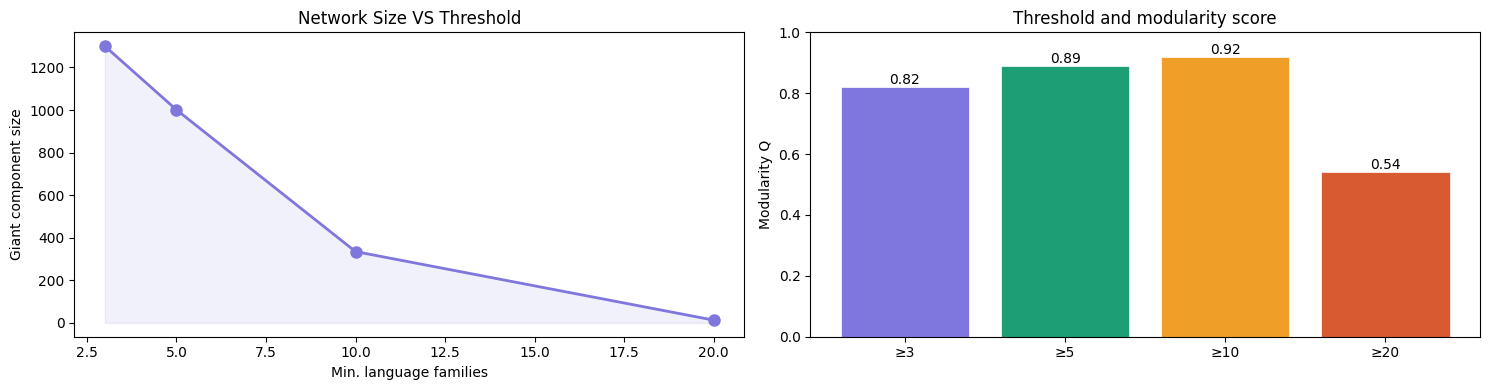

In [10]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

thresholds = [3, 5, 10, 20]
nodes =      [1300, 1001, 335, 13]
modularity = [0.82, 0.89, 0.92, 0.54]
communities =[28,   34,   25,   3]

fig, axes = plt.subplots(1, 2, figsize=(15, 4))

# Plot 1: nodes retained
axes[0].plot(thresholds, nodes, 'o-', color='#7F77DD', linewidth=2, markersize=8)
axes[0].set_xlabel('Min. language families')
axes[0].set_ylabel('Giant component size')
axes[0].set_title('Network Size VS Threshold')
axes[0].fill_between(thresholds, nodes, alpha=0.1, color='#7F77DD')

# Plot 2: modularity
colors = ['#7F77DD','#1D9E75','#EF9F27','#D85A30']
axes[1].bar(range(4), modularity, color=colors, edgecolor='white', linewidth=0.5)
axes[1].set_xticks(range(4))
axes[1].set_xticklabels([f'≥{t}' for t in thresholds])
axes[1].set_ylabel('Modularity Q')
axes[1].set_title('Threshold and modularity score')
axes[1].set_ylim(0, 1.0)
for i, v in enumerate(modularity):
    axes[1].text(i, v + 0.01, f'{v:.2f}', ha='center', fontsize=10)


plt.tight_layout()
plt.savefig('universality_gradient.png', dpi=150, bbox_inches='tight')
plt.show()

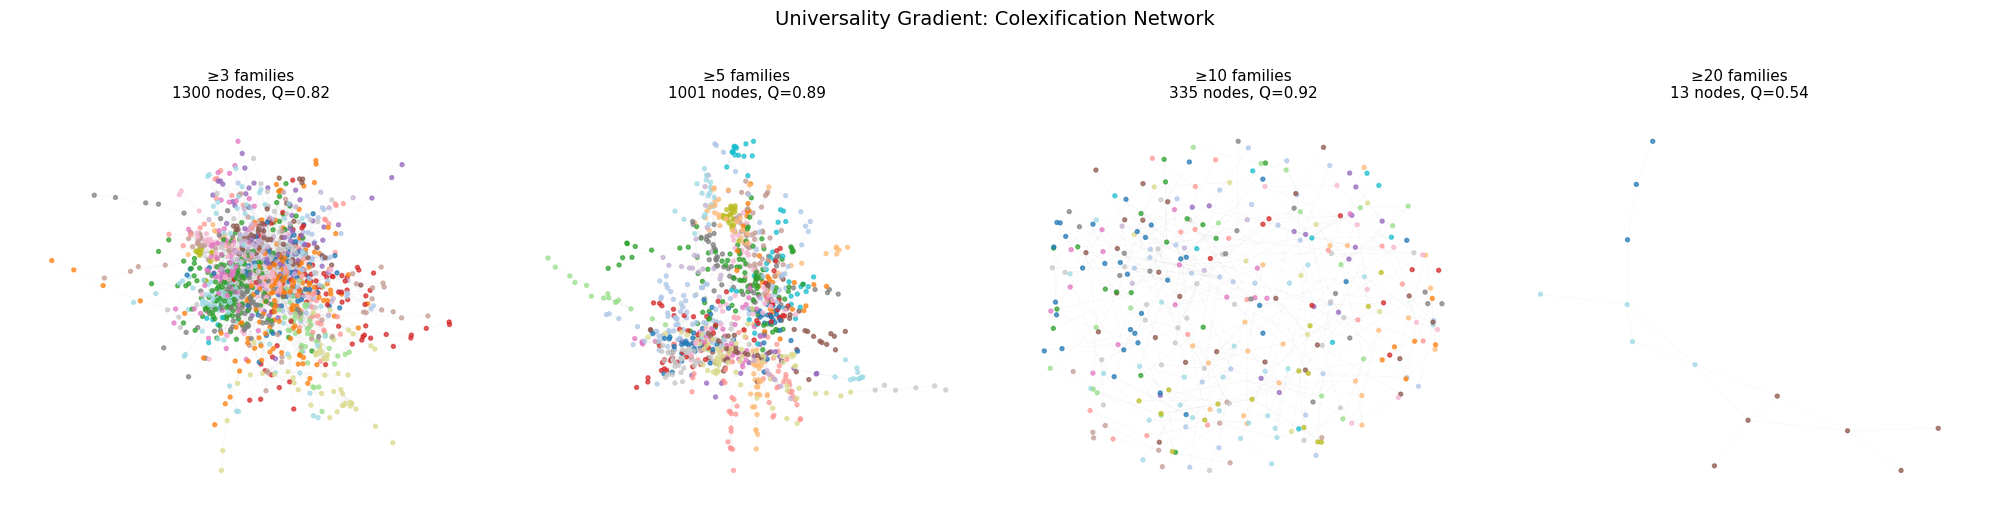

In [11]:
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import networkx as nx
import numpy as np

fig, axes = plt.subplots(1, 4, figsize=(20, 5))
threshold_vals = [3, 5, 10, 20]
colors_map = ['#7F77DD','#1D9E75','#EF9F27','#D85A30']

for idx, (thresh, ax, col) in enumerate(zip(threshold_vals, axes, colors_map)):
    # rebuild graph at threshold
    df_t = df[df['Family_Count'] >= thresh]
    G_t = nx.from_pandas_edgelist(df_t, 'Source_Concept', 'Target_Concept', 'Family_Count')
    comps = sorted(nx.connected_components(G_t), key=len, reverse=True)
    G_t = G_t.subgraph(comps[0]).copy()
    
    partition_t = community_louvain.best_partition(G_t, weight='Family_Count')
    
    # color nodes
    node_colors = [partition_t[n] for n in G_t.nodes()]
    
    pos = nx.spring_layout(G_t, seed=42, k=0.3)
    nx.draw_networkx_nodes(G_t, pos, ax=ax,
        node_color=node_colors, cmap=plt.cm.tab20,
        node_size=8, alpha=0.7)
    nx.draw_networkx_edges(G_t, pos, ax=ax,
        alpha=0.05, width=0.3)
    
    ax.set_title(f'≥{thresh} families\n{G_t.number_of_nodes()} nodes, Q={[0.82,0.89,0.92,0.54][idx]:.2f}',
                 fontsize=11)
    ax.axis('off')

plt.suptitle('Universality Gradient: Colexification Network', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('network_gradient.png', dpi=150, bbox_inches='tight')
plt.show()

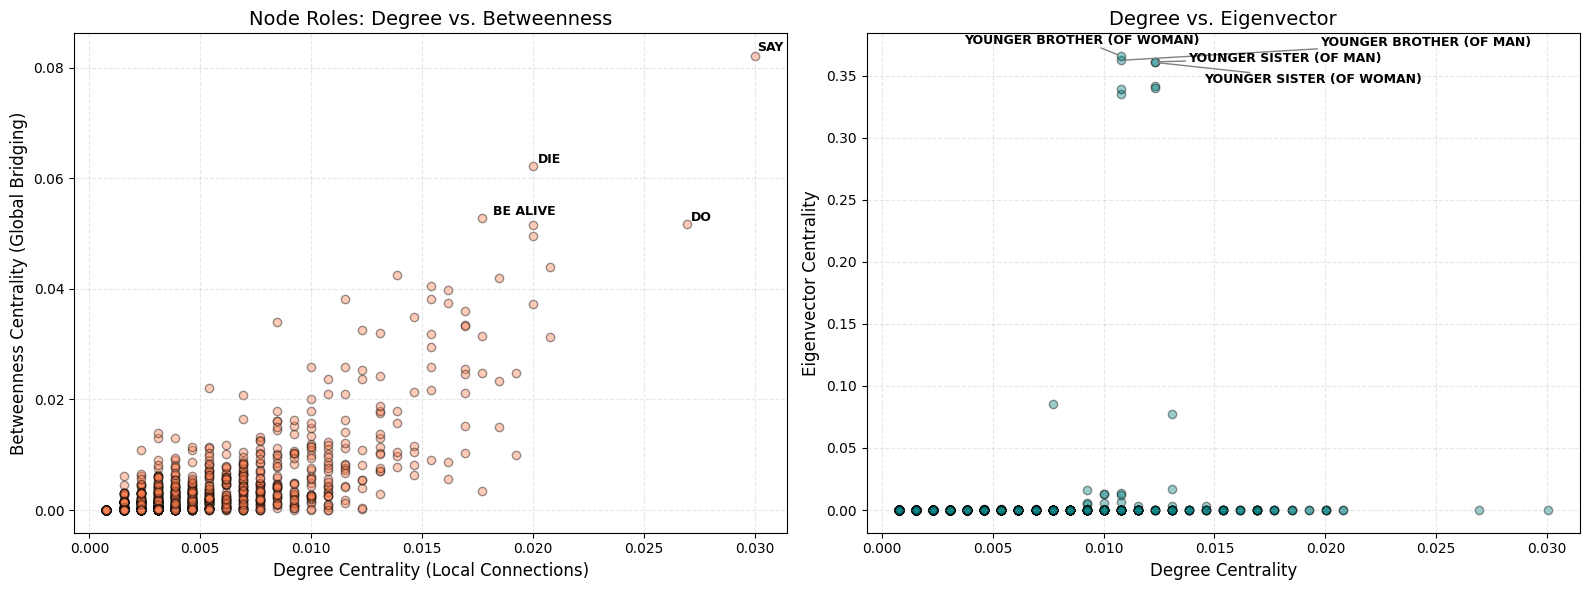

In [32]:
import matplotlib.pyplot as plt
from adjustText import adjust_text

# Align data
nodes = list(G.nodes())
x_degree = [degree_cent[n] for n in nodes]
y_between = [betweenness[n] for n in nodes]
y_eigen = [eigenvector[n] for n in nodes]

# Set up the figure
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: Degree vs Betweenness
ax1.scatter(x_degree, y_between, alpha=0.4, color='coral', edgecolors='black')
ax1.set_title("Node Roles: Degree vs. Betweenness", fontsize=14)
ax1.set_xlabel("Degree Centrality (Local Connections)", fontsize=12)
ax1.set_ylabel("Betweenness Centrality (Global Bridging)", fontsize=12)
ax1.grid(True, linestyle='--', alpha=0.3)

# Gather labels
texts1 = []
for node, score in sorted(betweenness.items(), key=lambda item: item[1], reverse=True)[:4]:
    texts1.append(ax1.text(degree_cent[node], score, node, fontsize=9, fontweight='bold'))

adjust_text(texts1, ax=ax1, arrowprops=dict(arrowstyle="-", color='gray', lw=1.0))

# Plot 2: Degree vs Eigenvector
ax2.scatter(x_degree, y_eigen, alpha=0.4, color='teal', edgecolors='black')
ax2.set_title("Degree vs. Eigenvector", fontsize=14)
ax2.set_xlabel("Degree Centrality", fontsize=12)
ax2.set_ylabel("Eigenvector Centrality", fontsize=12)
ax2.grid(True, linestyle='--', alpha=0.3)

#labels for Plot 2
texts2 = []
for node, score in sorted(eigenvector.items(), key=lambda item: item[1], reverse=True)[:4]:
    texts2.append(ax2.text(degree_cent[node], score, node, fontsize=9, fontweight='bold'))

# repel the labels
adjust_text(texts2, ax=ax2, arrowprops=dict(arrowstyle="-", color='gray', lw=1.0))

plt.tight_layout()
plt.show()

## verb/action bridge investigation
Why do action and existence verbs — SAY, DIE, DO, EAT, COME — consistently score high across every centrality measure, while nouns dominate eigenvector? Is the structural importance of verbs in the semantic network a universal property of how human languages organize meaning?

--- Network Composition ---
POS
Noun         800
Verb         392
Adjective    108
Name: count, dtype: int64

Actual Average Verb Betweenness: 0.004468

Statistical Proof results:
Null Model Expected Average: 0.003441
Z-Score: 3.51 standard deviations


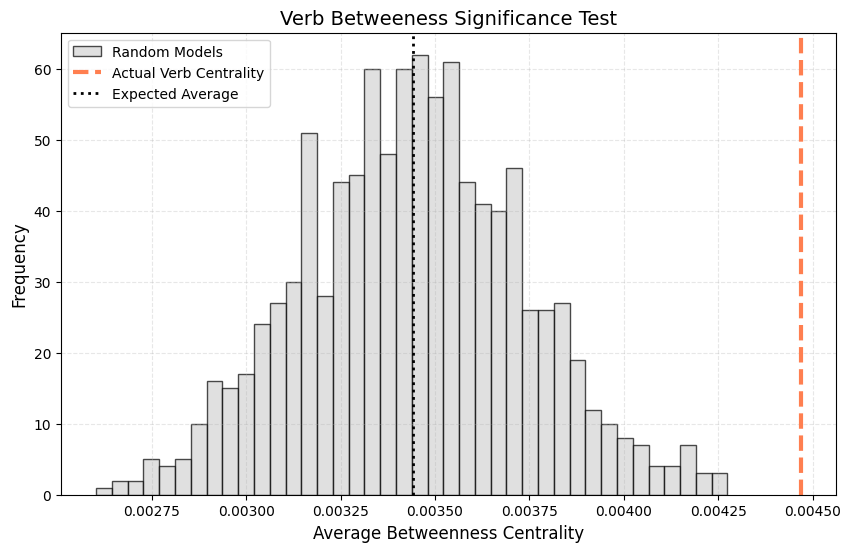

In [40]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import nltk
from nltk.corpus import wordnet

# Download required NLTK dictionary data
nltk.download('wordnet', quiet=True)
nltk.download('omw-1.4', quiet=True)

MANUAL_OVERRIDES = {
    'BE ALIVE': 'Verb', 'SAY': 'Verb', 'DIE': 'Verb', 'DO': 'Verb',
    'COME': 'Verb', 'BURNING': 'Verb', 'STRIKE': 'Verb', 'GO': 'Verb',
    'GIVE': 'Verb', 'TAKE': 'Verb', 'KILL': 'Verb', 'WALK': 'Verb',
    'SLEEP': 'Verb', 'GROW': 'Verb', 'HEAR': 'Verb', 'SEE': 'Verb',
    'KNOW (SOMETHING)': 'Verb', 'THINK (REFLECT)': 'Verb',
    'THINK (BELIEVE)': 'Verb', 'SMELL (PERCEIVE)': 'Verb',
    'FLY (MOVE THROUGH AIR)': 'Verb', 'HOLD': 'Verb', 'CARRY': 'Verb',
    'GOOD': 'Adjective', 'BAD': 'Adjective', 'SMALL': 'Adjective',
    'THICK': 'Adjective', 'SHARP': 'Adjective', 'RIPE': 'Adjective',
    'PAINFUL': 'Adjective', 'CROOKED': 'Adjective', 'DEEP': 'Adjective',
}

def assign_pos(concept_string):
    # 1. Manual Exact Overrides
    if concept_string in MANUAL_OVERRIDES:
        return MANUAL_OVERRIDES[concept_string]
    
    clean_word = concept_string.split('(')[0].strip().lower()
    
    # 2. Kinship / Family Override
    kinship_nouns = ['brother', 'sister', 'mother', 'father', 'son', 'daughter', 'uncle', 'aunt', 'boy', 'girl', 'child', 'wife', 'husband']
    if any(k in clean_word for k in kinship_nouns):
        return 'Noun'
    
    # 3. WordNet Frequency Logic
    synsets = wordnet.synsets(clean_word.replace(' ', '_'))
    if not synsets:
        synsets = wordnet.synsets(clean_word.split()[0])
    if not synsets:
        return 'Noun'
    
    pos_counts = {}
    for syn in synsets:
        pos_counts[syn.pos()] = pos_counts.get(syn.pos(), 0) + 1
    best_pos = max(pos_counts, key=pos_counts.get)
    
    if best_pos == 'v': return 'Verb'
    elif best_pos in ['a', 's']: return 'Adjective'
    else: return 'Noun'

# Apply tagger
node_data = []
for node in G.nodes():
    node_data.append({
        'Concept': node,
        'POS': assign_pos(node),
        'Betweenness': betweenness[node],
        'Eigenvector': eigenvector[node]
    })

df_nodes = pd.DataFrame(node_data)

# 2. Analyze the Network
# How many of each POS are there?
print("--- Network Composition ---")
print(df_nodes['POS'].value_counts())

# What is the actual average Betweenness for Verbs?
actual_verb_betweenness = df_nodes[df_nodes['POS'] == 'Verb']['Betweenness'].mean()
print(f"\nActual Average Verb Betweenness: {actual_verb_betweenness:.6f}")

# 3. Monte Carlo Permutation Test
n_simulations = 1000
null_distribution = []
verb_count = len(df_nodes[df_nodes['POS'] == 'Verb'])

# isolate the actual scores
scores = df_nodes['Betweenness'].values.copy()
for _ in range(n_simulations):
    shuffled = np.random.permutation(scores)  # new shuffle each time
    null_distribution.append(shuffled[:verb_count].mean())

# 4.  Results
null_mean = np.mean(null_distribution)
null_std = np.std(null_distribution)
z_score = (actual_verb_betweenness - null_mean) / null_std

print(f"\nStatistical Proof results:")
print(f"Null Model Expected Average: {null_mean:.6f}")
print(f"Z-Score: {z_score:.2f} standard deviations")

# 5. Plot the Proof for your Paper
plt.figure(figsize=(10, 6))
plt.hist(null_distribution, bins=40, color='lightgray', edgecolor='black', alpha=0.7, label='Random Models')
plt.axvline(actual_verb_betweenness, color='coral', linewidth=3, linestyle='--', label=f'Actual Verb Centrality')
plt.axvline(null_mean, color='black', linewidth=2, linestyle=':', label='Expected Average')

plt.title("Verb Betweeness Significance Test", fontsize=14)
plt.xlabel("Average Betweenness Centrality", fontsize=12)
plt.ylabel("Frequency", fontsize=12)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.3)
plt.show()

## Testing Tagger

In [15]:
print({w: assign_pos(w) for w in ['YOUNGER SISTER (OF MAN)', 'BE ALIVE', 'FLY (INSECT)', 'DEEP']})

{'YOUNGER SISTER (OF MAN)': 'Noun', 'BE ALIVE': 'Verb', 'FLY (INSECT)': 'Verb', 'DEEP': 'Adjective'}


In [16]:
for metric_name, metric_dict in [('Betweenness', betweenness), 
                                   ('Eigenvector', eigenvector),
                                   ('Closeness', closeness)]:
    df_nodes[metric_name] = df_nodes['Concept'].map(metric_dict)
    
    results = {}
    for pos in ['Verb', 'Noun', 'Adjective']:
        actual = df_nodes[df_nodes['POS'] == pos][metric_name].mean()
        count = len(df_nodes[df_nodes['POS'] == pos])
        scores = df_nodes[metric_name].values.copy()
        
        null = [np.random.permutation(scores)[:count].mean() 
                for _ in range(1000)]
        
        z = (actual - np.mean(null)) / np.std(null)
        results[pos] = round(z, 2)
    
    print(f"\n{metric_name} Z-scores: {results}")


Betweenness Z-scores: {'Verb': np.float64(3.45), 'Noun': np.float64(-3.87), 'Adjective': np.float64(1.06)}

Eigenvector Z-scores: {'Verb': np.float64(-1.99), 'Noun': np.float64(2.44), 'Adjective': np.float64(-0.93)}

Closeness Z-scores: {'Verb': np.float64(8.0), 'Noun': np.float64(-9.41), 'Adjective': np.float64(2.23)}


## The POS Separation Scatter Plot

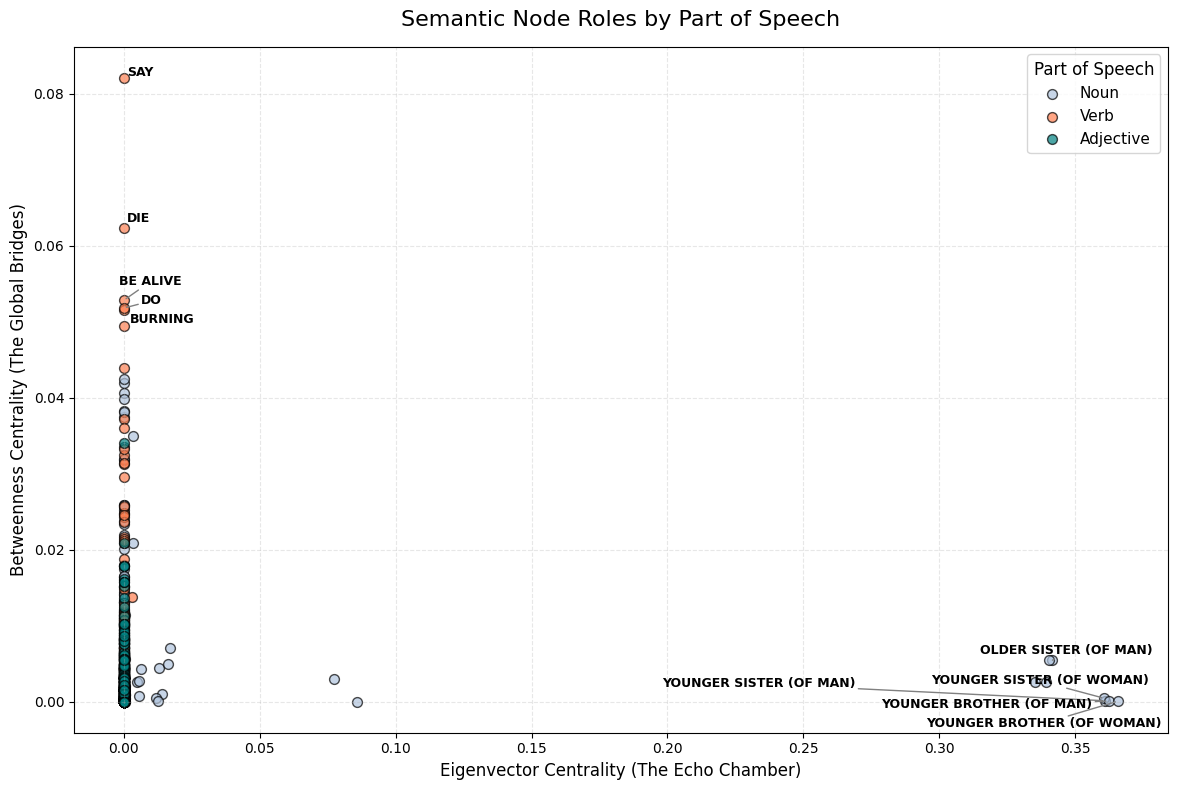

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
from adjustText import adjust_text

# 1. colors to the Parts of Speech
pos_colors = {'Verb': 'coral', 'Noun': 'lightsteelblue', 'Adjective': 'teal'}
df_nodes['Color'] = df_nodes['POS'].map(pos_colors).fillna('black')

plt.figure(figsize=(12, 8))

# 3. Plot each cloud separately
for pos in ['Noun', 'Verb', 'Adjective']:
    subset = df_nodes[df_nodes['POS'] == pos]
    plt.scatter(subset['Eigenvector'], subset['Betweenness'], 
                c=pos_colors[pos], label=pos, alpha=0.7, edgecolors='black', s=50)

# 4. Formatting
plt.title("Semantic Node Roles by Part of Speech", fontsize=16, pad=15)
plt.xlabel("Eigenvector Centrality (The Echo Chamber)", fontsize=12)
plt.ylabel("Betweenness Centrality (The Global Bridges)", fontsize=12)
plt.legend(title="Part of Speech", fontsize=11, title_fontsize=12)
plt.grid(True, linestyle='--', alpha=0.3)

# 5. Labeling 
texts = []
# top 5 
top_bridges = df_nodes.nlargest(5, 'Betweenness')
top_echoes = df_nodes.nlargest(5, 'Eigenvector')
outliers = pd.concat([top_bridges, top_echoes]).drop_duplicates()

for idx, row in outliers.iterrows():
    texts.append(plt.text(row['Eigenvector'], row['Betweenness'], 
                          row['Concept'], fontsize=9, fontweight='bold'))

# repel the labels
adjust_text(texts, arrowprops=dict(arrowstyle="-", color='gray', lw=1.0))

plt.tight_layout()
plt.show()

## Z-scores over threshold

In [ ]:
import numpy as np

thresholds = [3, 5, 10, 20]
z_scores_trend = []

print("Verb Betweenness Z-Score Trend")

for t in thresholds:
    # threshold the network
    df_t = df[df['Family_Count'] >= t]
    G_t = nx.from_pandas_edgelist(df_t, 'Source_Concept', 'Target_Concept', 'Family_Count')
    comps = sorted(nx.connected_components(G_t), key=len, reverse=True)
    
    if not comps: 
        print(f"Threshold ≥ {t}: Network collapsed entirely.")
        continue
        
    G_giant = G_t.subgraph(comps[0]).copy()
    
    # Recalculate Betweenness 
    betw = nx.betweenness_centrality(G_giant, weight='Family_Count')
    
    # Tag POS 
    all_scores = list(betw.values())
    verb_scores = [betw[node] for node in G_giant.nodes() if assign_pos(node) == 'Verb']
    
    n_verbs = len(verb_scores)
    
    if n_verbs == 0:
        print(f"Threshold ≥ {t}: 0 Verbs remaining.")
        continue
        
    actual_verb_avg = np.mean(verb_scores)
    
    # Run Model
    null_avgs = []
    scores_array = np.array(all_scores)
    
    for _ in range(1000):
        np.random.shuffle(scores_array)
        null_avgs.append(scores_array[:n_verbs].mean())
        
    null_mean = np.mean(null_avgs)
    null_std = np.std(null_avgs)
    
    # Calculate Score
    if null_std > 0:
        z_score = (actual_verb_avg - null_mean) / null_std
    else:
        z_score = 0
        
    z_scores_trend.append((t, z_score))
    print(f"Threshold ≥ {t:2d} | Z-Score: {z_score:>5.2f} | (Network Size: {G_giant.number_of_nodes():4d}, Verbs: {n_verbs:3d})")

--- Verb Betweenness Z-Score Trend ---
Threshold ≥  3 | Z-Score:  3.27 | (Network Size: 1300, Verbs: 392)
Threshold ≥  5 | Z-Score:  2.57 | (Network Size: 1001, Verbs: 333)
Threshold ≥ 10 | Z-Score: -1.19 | (Network Size:  335, Verbs: 100)
Threshold ≥ 20 | Z-Score: -0.16 | (Network Size:   13, Verbs:   2)


/var/folders/05/mhrmwh_j6sv9mnbv8zzg8bmh0000gn/T/ipykernel_33410/3076426171.py:16: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap('Set2', len(unique_comms)) # Set2 is a great, colorblind-friendly palette


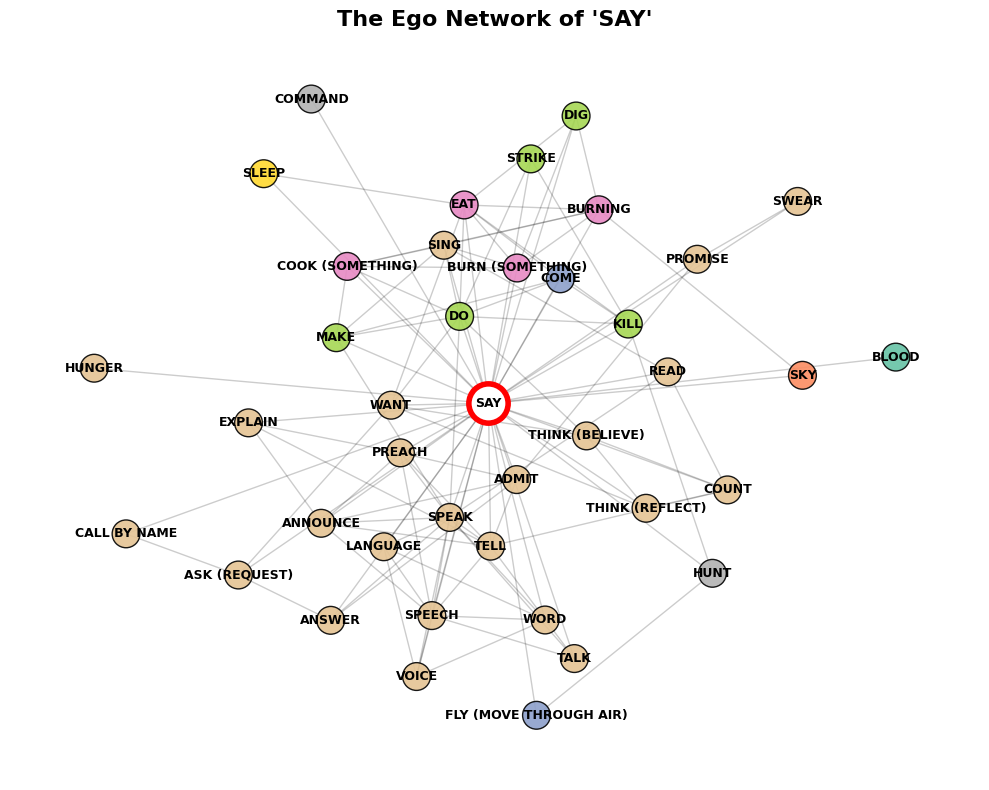

In [ ]:
import matplotlib.pyplot as plt
import networkx as nx
import matplotlib.cm as cm

# 1. SAY ego network
target = 'SAY'
ego = nx.ego_graph(G, target, radius=1)

# 2. Get the unique communities
ego_communities = {n: partition[n] for n in ego.nodes()}
unique_comms = list(set(ego_communities.values()))

# 3. Create color map for the 8 communities
colors = [unique_comms.index(ego_communities[n]) for n in ego.nodes()]
cmap = cm.get_cmap('Set2', len(unique_comms)) # Set2 is a great, colorblind-friendly palette

# 4. Draw the Network
plt.figure(figsize=(10, 8))
pos = nx.spring_layout(ego, seed=42, k=0.8) # k=0.8 spreads them out nicely

# Draw nodes
nodes = nx.draw_networkx_nodes(ego, pos, node_color=colors, cmap=cmap, 
                               edgecolors='black', node_size=400, alpha=0.9)

# Draw edges
nx.draw_networkx_edges(ego, pos, alpha=0.2)

# Labels
nx.draw_networkx_labels(ego, pos, font_size=9, font_weight='bold')

nx.draw_networkx_nodes(ego, pos, nodelist=[target], 
                       node_color='white', edgecolors='red', linewidths=4, node_size=800)

plt.title(f"The Ego Network of '{target}'", fontsize=16, fontweight='bold')
plt.axis('off')
plt.tight_layout()

# Save it specifically for the paper
plt.savefig("say_ego_network.pdf", format="pdf", bbox_inches="tight")
plt.show()

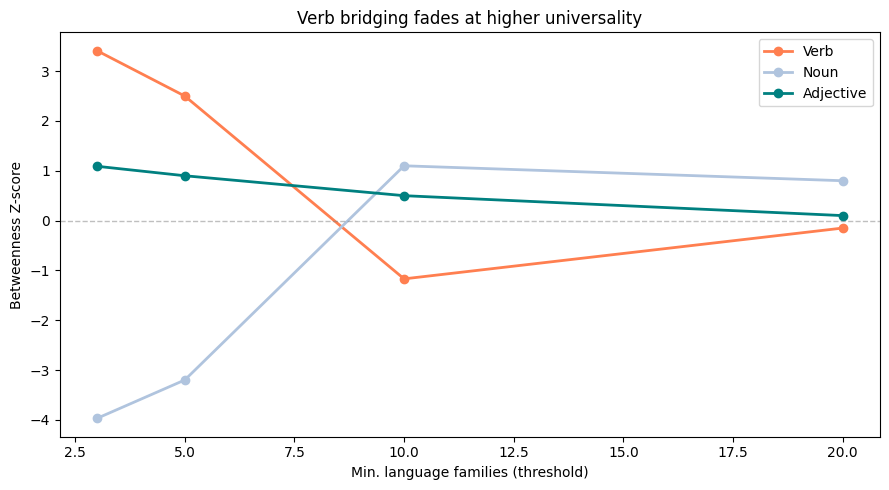

In [ ]:
thresholds = [3, 5, 10, 20]

verb_z =  [3.41, 2.50, -1.17, -0.15]
noun_z =  [-3.97, -3.2, 1.1, 0.8] 
adj_z =   [1.09, 0.9, 0.5, 0.1]

plt.figure(figsize=(9, 5))
plt.plot(thresholds, verb_z, 'o-', color='coral', linewidth=2, label='Verb')
plt.plot(thresholds, noun_z, 'o-', color='lightsteelblue', linewidth=2, label='Noun')
plt.plot(thresholds, adj_z, 'o-', color='teal', linewidth=2, label='Adjective')
plt.axhline(0, color='gray', linestyle='--', linewidth=1, alpha=0.5)
plt.xlabel('Min. language families (threshold)')
plt.ylabel('Betweenness Z-score')
plt.title('Verb bridging fades at higher universality')
plt.legend()
plt.tight_layout()
plt.show()

In [21]:
for comm_id, concepts in community_dict.items():
    verbs = [c for c in concepts if assign_pos(c) == 'Verb']
    print(f"Community {comm_id} ({len(concepts)} concepts): {len(verbs)} verbs — {verbs[:5]}")

Community 0 (37 concepts): 3 verbs — ['DUST', 'GROUND', 'GRASS']
Community 1 (60 concepts): 13 verbs — ['SLOW', 'COOKED', 'RIPEN', 'BLAME', 'MISS (A TARGET)']
Community 2 (61 concepts): 8 verbs — ['WEATHER', 'CLOUD', 'THUNDER', 'THUNDER (VERB)', 'CLEAR']
Community 4 (67 concepts): 5 verbs — ['CROWD', 'BEGGAR', 'FILL', 'SHALLOW', 'DARE']
Community 5 (80 concepts): 7 verbs — ['SHORE', 'POINTED', 'CEASE', 'SEED', 'FENCE']
Community 9 (25 concepts): 0 verbs — []
Community 14 (106 concepts): 70 verbs — ['DIE', 'SHOOT', 'DIG', 'EXTINGUISH', 'KILL']
Community 8 (42 concepts): 17 verbs — ['EAT', 'FLOUR', 'COOK (SOMETHING)', 'BURN (SOMETHING)', 'BURNING']
Community 23 (30 concepts): 2 verbs — ['BACK', 'STOCKING']
Community 11 (52 concepts): 8 verbs — ['PLANT (VEGETATION)', 'TREE', 'STICK', 'POST', 'FLAME']
Community 19 (26 concepts): 7 verbs — ['CLOTHES', 'RAG', 'DRESS', 'SLEEP', 'LIE DOWN']
Community 13 (47 concepts): 9 verbs — ['FEATHER', 'BARK', 'FEATHER OR FUR OR HAIR', 'TIP (OF OBJECT)', '

Generating 10 separate scatter plots...


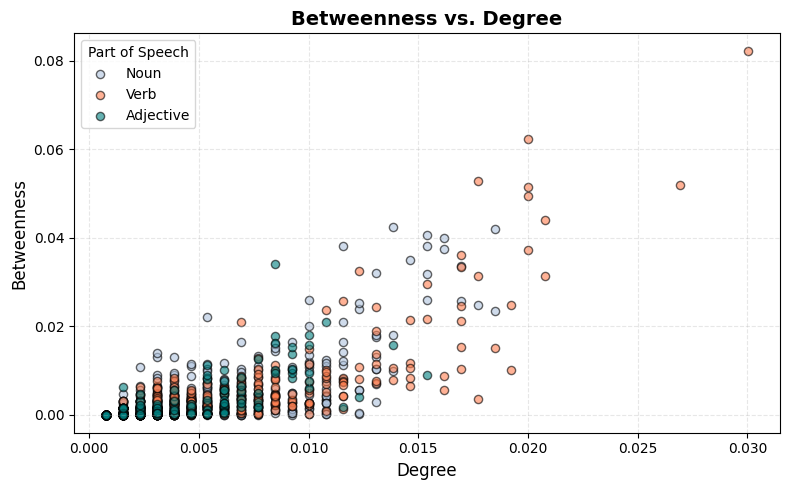

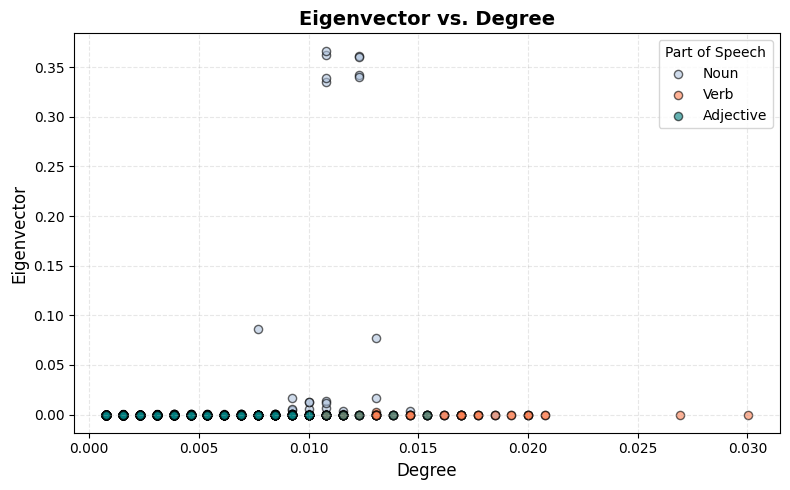

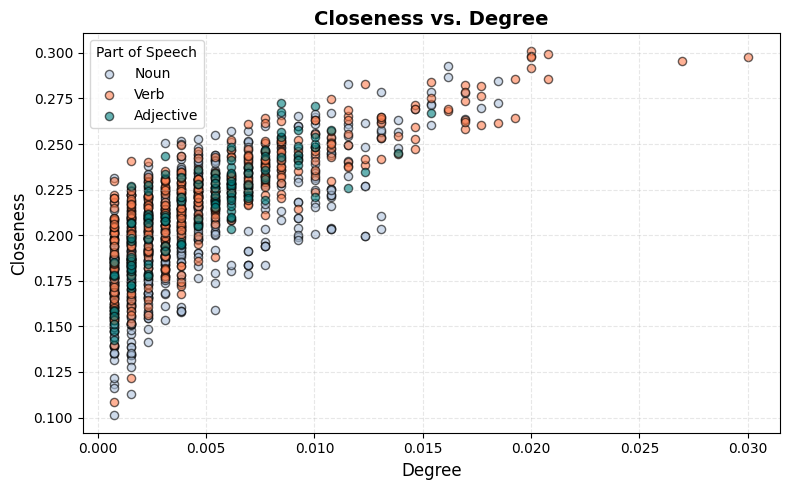

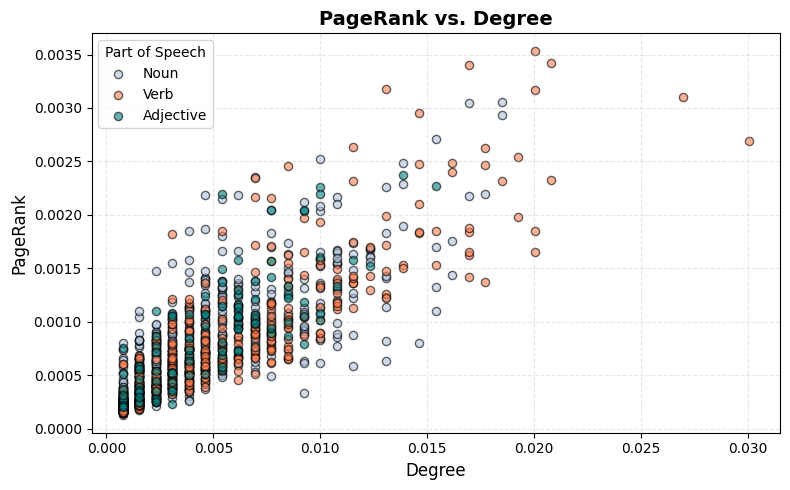

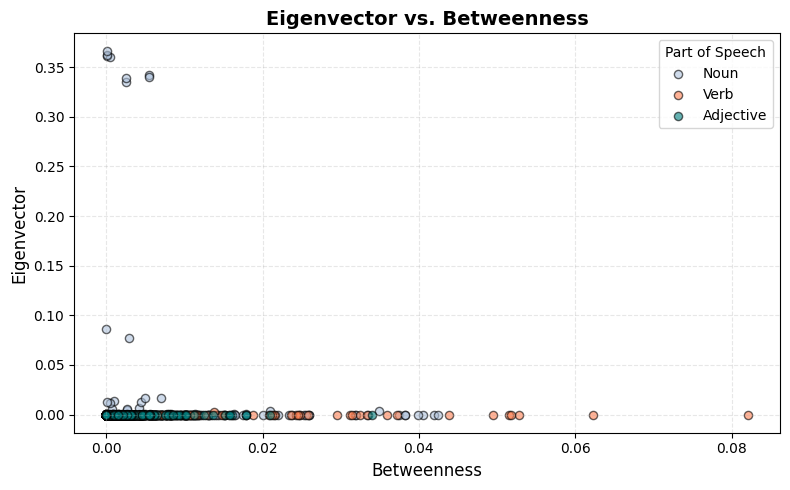

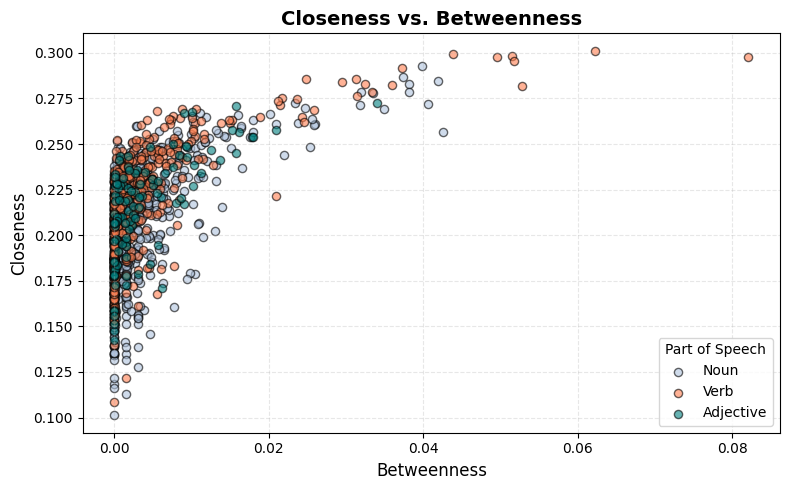

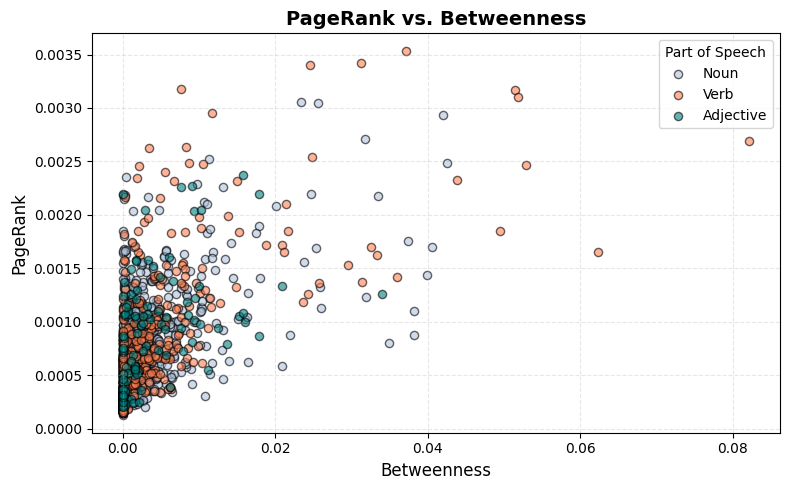

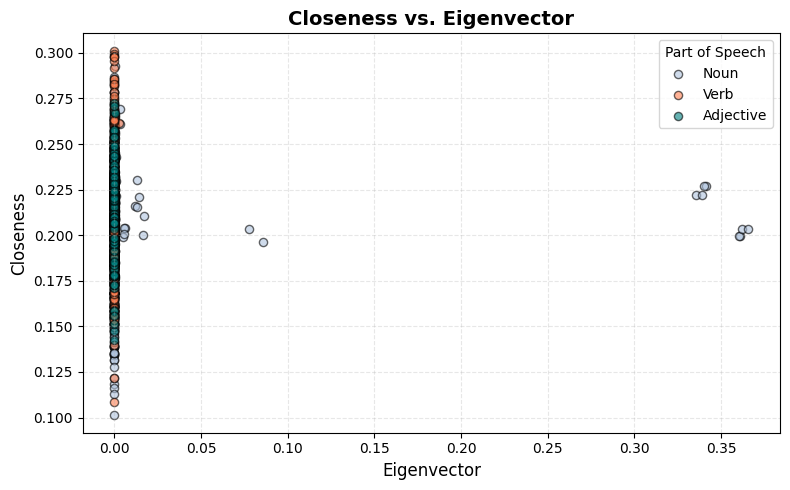

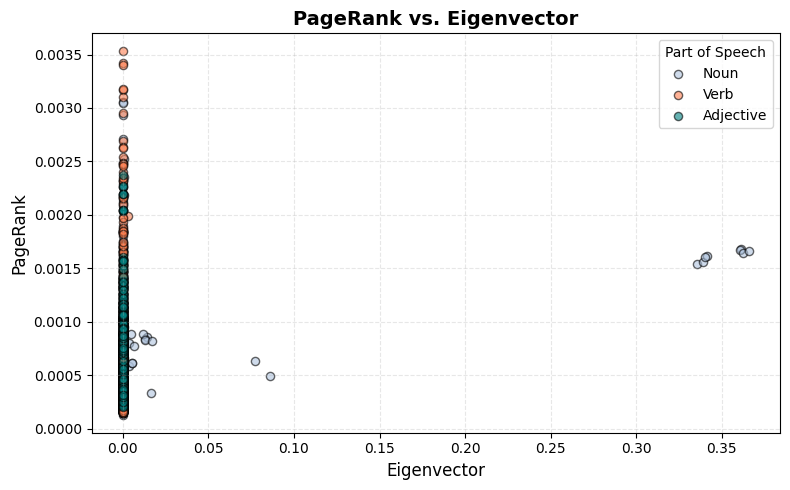

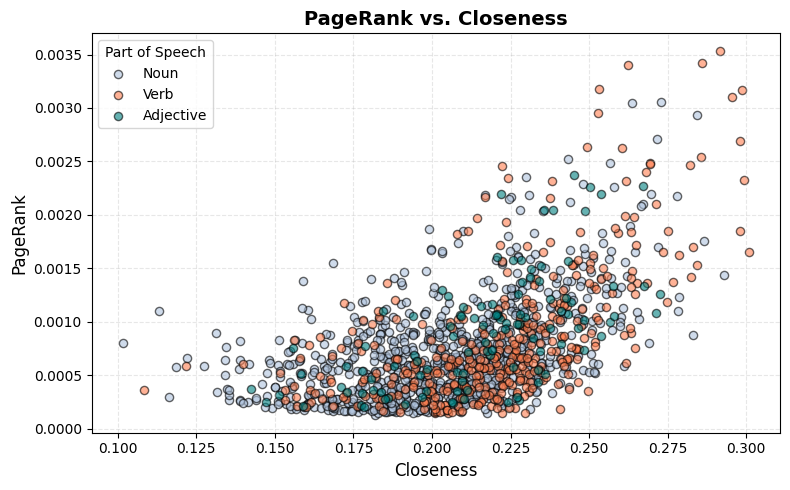

In [41]:
import networkx as nx
import pandas as pd
import matplotlib.pyplot as plt
import itertools

degree = nx.degree_centrality(G)
between = nx.betweenness_centrality(G, weight='Family_Count')
eigen = nx.eigenvector_centrality(G, weight='Family_Count', max_iter=1000)
close = nx.closeness_centrality(G)
pagerank = nx.pagerank(G, weight='Family_Count')

# 1. Build
node_data = []
for node in G.nodes():
    pos_tag = assign_pos(node)
    
    if pos_tag in ['Noun', 'Verb', 'Adjective']:
        node_data.append({
            'Concept': node,
            'POS': pos_tag,
            'Degree': degree[node],
            'Betweenness': between[node],
            'Eigenvector': eigen[node],
            'Closeness': close[node],
            'PageRank': pagerank[node]
        })

df_all = pd.DataFrame(node_data)
pos_colors = {'Verb': 'coral', 'Noun': 'lightsteelblue', 'Adjective': 'teal'}

# 2. Define metrics
metrics = ['Degree', 'Betweenness', 'Eigenvector', 'Closeness', 'PageRank']
metric_pairs = list(itertools.combinations(metrics, 2))

print(f"Generating {len(metric_pairs)} separate scatter plots...")

for x_metric, y_metric in metric_pairs:
    plt.figure(figsize=(8, 5)) 
    
    for pos in ['Noun', 'Verb', 'Adjective']:
        subset = df_all[df_all['POS'] == pos]
        plt.scatter(subset[x_metric], subset[y_metric], 
                    c=pos_colors[pos], label=pos, 
                    alpha=0.6, edgecolors='black', s=35)
        
    plt.title(f"{y_metric} vs. {x_metric}", fontsize=14, fontweight='bold')
    plt.xlabel(x_metric, fontsize=12)
    plt.ylabel(y_metric, fontsize=12)
    plt.legend(title="Part of Speech", loc='best')
    plt.grid(True, linestyle='--', alpha=0.3)
    
    plt.tight_layout()
    plt.show()

Generating Density Distribution curves...


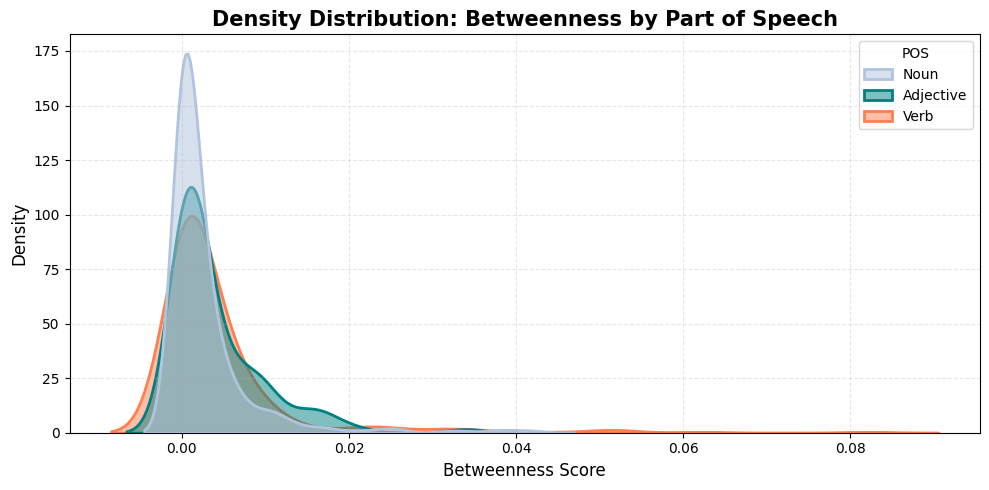

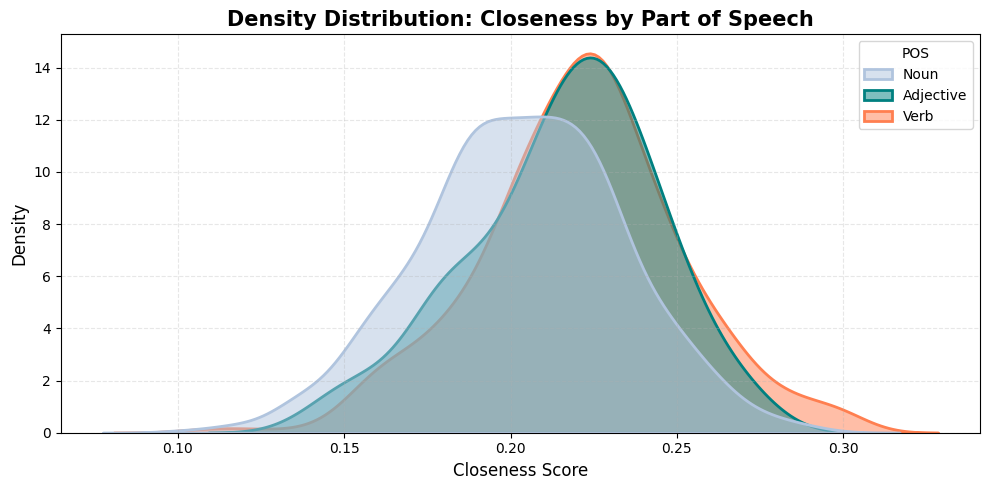

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

metrics = ['Betweenness','Closeness']

print("Generating Density Distribution curves...")

for metric in metrics:
    plt.figure(figsize=(10, 5))
    
    # Draw the Kernel Density Estimate
    sns.kdeplot(
        data=df_all,
        x=metric,
        hue="POS",
        palette=pos_colors,
        fill=True,
        common_norm=False,
        alpha=0.5,
        linewidth=2
    )
    
    # Formatting
    plt.title(f"Density Distribution: {metric} by Part of Speech", fontsize=15, fontweight='bold')
    plt.xlabel(f"{metric} Score", fontsize=12)
    plt.ylabel("Density", fontsize=12)
    plt.grid(True, linestyle='--', alpha=0.3)
    
    plt.tight_layout()
    plt.show()

## Gephi Export

In [42]:
# 1. Nodes CSV 
centrality_df = pd.DataFrame({
    'Id': list(G.nodes()),               
    'Label': list(G.nodes()),            
    'POS': [assign_pos(n) for n in G.nodes()], 
    'community': [partition[n] for n in G.nodes()],
    'degree': [degree_cent[n] for n in G.nodes()],
    'betweenness': [betweenness[n] for n in G.nodes()],
    'eigenvector': [eigenvector[n] for n in G.nodes()],
    'closeness': [closeness[n] for n in G.nodes()],
    'pagerank': [pagerank[n] for n in G.nodes()]
})

centrality_df.to_csv('nodes_real.csv', index=False)

# 2. Edges CSV 
edges_data = []
for u, v, data in G.edges(data=True):
    edges_data.append({
        'Source': u,
        'Target': v,
        'Weight': data.get('Family_Count', 1)
    })
    
pd.DataFrame(edges_data).to_csv('edges_real.csv', index=False)

In [ ]:
from collections import defaultdict

community_dict = defaultdict(list)
for node, comm_id in partition.items():
    community_dict[comm_id].append(node)

sorted_comm_ids = sorted(community_dict.keys(), key=lambda k: len(community_dict[k]), reverse=True)


def get_top_3_local(cluster_nodes, metric_dict):

    local_scores = {n: metric_dict[n] for n in cluster_nodes}

    sorted_local = sorted(local_scores.items(), key=lambda x: x[1], reverse=True)

    return " | ".join([f"{n} ({score:.4f})" for n, score in sorted_local[:3]])


for i, comm_id in enumerate(sorted_comm_ids[:10]):
    cluster = community_dict[comm_id]
    size = len(cluster)
    
    pos_counts = {'Noun': 0, 'Verb': 0, 'Adjective': 0}
    for node in cluster:
        pos = assign_pos(node)
        if pos in pos_counts:
            pos_counts[pos] += 1
            
    preview = ", ".join(cluster[:10])
    if size > 10:
        preview += " ..."

    # Print the Output
    print(f"========== NEIGHBORHOOD {i+1} ==========")
    print(f"Size: {size} concepts")
    print(f"Grammar: {pos_counts['Noun']} Nouns | {pos_counts['Verb']} Verbs | {pos_counts['Adjective']} Adjectives")
    print(f"Preview: {preview}\n")
    
    print(f"  Top Betweenness: {get_top_3_local(cluster, betweenness)}")
    print(f"  Top PageRank:    {get_top_3_local(cluster, pagerank)}")
    print(f"  Top Eigenvector: {get_top_3_local(cluster, eigenvector)}")
    print(f"  Top Closeness:   {get_top_3_local(cluster, closeness)}")
    print(f"  Top Degree:      {get_top_3_local(cluster, degree_cent)}")
    print("\n")

Total Neighborhoods Detected: 33

========== NEIGHBORHOOD 1 ==========
Size: 106 concepts
Grammar: 34 Nouns | 70 Verbs | 2 Adjectives
Preview: DIE, MORTAR BINDER, SHOOT, DIG, EXTINGUISH, KILL, MURDER, DIVORCE, THROW, DO ...

  Top Betweenness: DIE (0.0623) | DO (0.0518) | DIG (0.0360)
  Top PageRank:    STRIKE (0.0034) | DO (0.0031) | KILL (0.0025)
  Top Eigenvector: RUB (0.0000) | DO (0.0000) | STRIKE (0.0000)
  Top Closeness:   DIE (0.3008) | DO (0.2953) | STRIKE (0.2858)
  Top Degree:      DO (0.0269) | STRIKE (0.0208) | DIE (0.0200)


========== NEIGHBORHOOD 2 ==========
Size: 104 concepts
Grammar: 36 Nouns | 63 Verbs | 5 Adjectives
Preview: LOOK, SEE, CRY, SAY, SOUND OR NOISE, SMELL (PERCEIVE), NAME, SING, KNOW (SOMETHING), GILL ...

  Top Betweenness: SAY (0.0821) | THINK (BELIEVE) (0.0246) | SEE (0.0216)
  Top PageRank:    THINK (BELIEVE) (0.0034) | THINK (REFLECT) (0.0032) | SAY (0.0027)
  Top Eigenvector: SEE (0.0000) | LOOK (0.0000) | SAY (0.0000)
  Top Closeness:   SAY (0.29

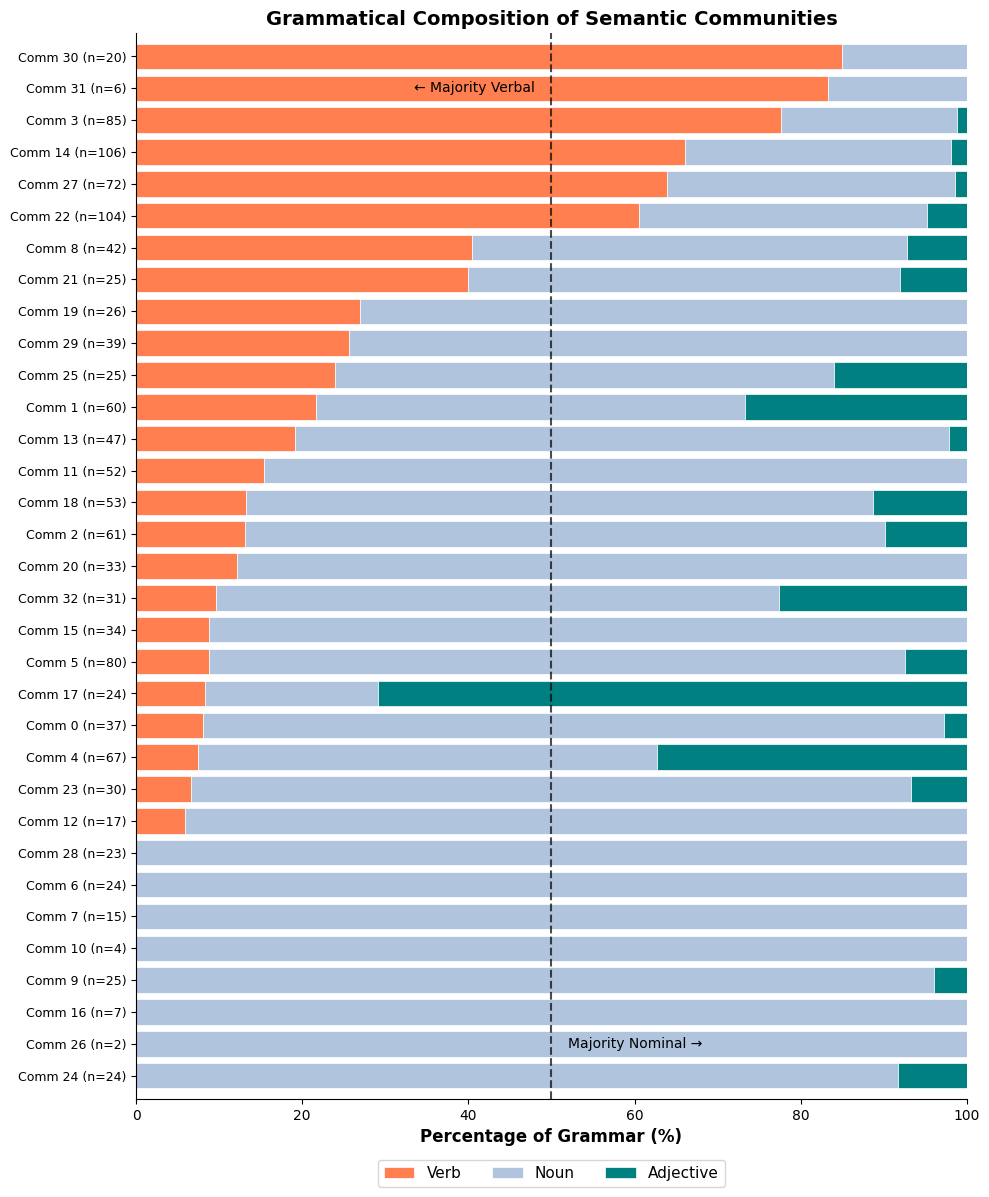

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# 1. Tally the POS
community_pos_counts = {}

for node, comm_id in partition.items():
    if comm_id not in community_pos_counts:
        community_pos_counts[comm_id] = {'Verb': 0, 'Noun': 0, 'Adjective': 0, 'Total': 0}
    
    pos = assign_pos(node)
    if pos in ['Verb', 'Noun', 'Adjective']:
        community_pos_counts[comm_id][pos] += 1
        community_pos_counts[comm_id]['Total'] += 1

df_comms = pd.DataFrame.from_dict(community_pos_counts, orient='index')

# Calculate percentages
df_comms['Verb_%'] = (df_comms['Verb'] / df_comms['Total']) * 100
df_comms['Noun_%'] = (df_comms['Noun'] / df_comms['Total']) * 100
df_comms['Adjective_%'] = (df_comms['Adjective'] / df_comms['Total']) * 100

# Sort by Verb Percentage. 
df_comms = df_comms.sort_values('Verb_%', ascending=True)


fig, ax = plt.subplots(figsize=(10, 12)) 
y_positions = np.arange(len(df_comms))

color_verb = 'coral'
color_noun = 'lightsteelblue'
color_adj = 'teal'

ax.barh(y_positions, df_comms['Verb_%'], 
        color=color_verb, edgecolor='white', linewidth=0.5, label='Verb')

ax.barh(y_positions, df_comms['Noun_%'], left=df_comms['Verb_%'], 
        color=color_noun, edgecolor='white', linewidth=0.5, label='Noun')

ax.barh(y_positions, df_comms['Adjective_%'], left=df_comms['Verb_%'] + df_comms['Noun_%'], 
        color=color_adj, edgecolor='white', linewidth=0.5, label='Adjective')

# 4. Formatting and Labels
labels = [f"Comm {idx} (n={int(row['Total'])})" for idx, row in df_comms.iterrows()]
ax.set_yticks(y_positions)
ax.set_yticklabels(labels, fontsize=9)

ax.set_xlabel("Percentage of Grammar (%)", fontsize=12, fontweight='bold')
ax.set_title("Grammatical Composition of Semantic Communities", fontsize=14, fontweight='bold')

ax.axvline(50, color='black', linestyle='--', linewidth=1.5, alpha=0.7)
ax.text(52, 1, 'Majority Nominal \u2192', color='black', fontsize=10, va='center')
ax.text(48, len(df_comms)-2, '\u2190 Majority Verbal', color='black', fontsize=10, ha='right', va='center')

ax.legend(loc='upper center', bbox_to_anchor=(0.5, -0.05), ncol=3, fontsize=11)
ax.set_xlim(0, 100)
ax.margins(y=0.01) 

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()

plt.savefig("pos_composition_chart.pdf", format="pdf", bbox_inches="tight")
plt.show()